In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Import physics libraries from lib.py
from lib import (
    MaterialDatabase, 
    NuclearDatabase,
    calculate_bethe_bloch,
    calculate_capture_probability,
    calculate_specific_neutron_case,
    compare_materials_at_energy
)

# Initialize databases
material_db = MaterialDatabase()
nuclear_db = NuclearDatabase()

print("✓ All libraries and databases loaded successfully!")

✓ All libraries and databases loaded successfully!


# Neutron Capture Probability Calculator

This notebook calculates the **probability of neutron capture** as a function of neutron energy for different materials, taking into account material properties and geometry.

## Features

⚛️ **Comprehensive Nuclear Database**: Includes thermal neutron cross-sections, resonance parameters, and fast neutron data for key isotopes

🎛️ **Configurable Parameters**: Easy selection of materials, density, thickness, and temperature

📊 **Multiple Plot Types**: Cross-sections, capture probabilities, thickness dependence, temperature effects

🌡️ **Temperature Effects**: Accurate 1/v law implementation with thermal motion corrections

🎯 **Interactive Analysis**: Functions for specific calculations and material comparisons

🔧 **keV Energy Units**: All energy inputs/outputs use keV for convenience (converted internally to eV for calculations)

## Key Physics

The neutron capture probability is governed by:

$$P = 1 - e^{-\Sigma t}$$

Where:
- $\Sigma = n \sigma(E)$ = macroscopic cross-section (cm⁻¹)
- $n = \frac{\rho N_A \text{abundance}}{A}$ = number density (atoms/cm³)
- $\sigma(E)$ = energy-dependent microscopic cross-section (barns)
- $t$ = material thickness (cm)

### Cross-Section Models:
- **Thermal Region** (E < 100 eV): $\sigma(E) = \sigma_{th} \sqrt{\frac{E_{th}}{E}}$ (1/v law)
- **Resonance Region** (100 eV - 500 keV): Breit-Wigner resonance peaks
- **Fast Region** (E > 500 keV): Slowly varying cross-sections

### Energy Ranges:
- **Ultra-thermal**: < 0.1 eV (< 0.0001 keV)
- **Thermal**: 0.1 eV - 100 eV (0.0001 - 0.1 keV)
- **Epithermal**: 100 eV - 500 keV (0.1 - 500 keV)
- **Fast**: > 500 keV (> 0.5 MeV)

---

**📝 Instructions**: Modify the configuration parameters, then run all cells to generate comprehensive neutron capture analysis!

**🎯 Note**: Interface uses keV units for convenience, but calculations are performed in eV internally for compatibility with physics libraries.

In [66]:
# ===================================================================
# CONFIGURATION SECTION - MODIFY THESE PARAMETERS
# ===================================================================

# Select materials/isotopes to analyze
SELECTED_MATERIALS = [
    'B-10',      # Boron-10 (high thermal capture cross-section)
    'Cd-113',    # Cadmium-113 (strong neutron absorber)
    'Gd-155',    # Gadolinium-155 (excellent thermal absorber)
    'Gd-157',    # Gadolinium-157 (highest known thermal cross-section)
    'Li-6',      # Lithium-6 (neutron converter)
    'He-3',      # Helium-3 (neutron detector gas)
    'U-235',     # Uranium-235 (fissile material)
    'H-1',       # Hydrogen (moderator)
]

# Material properties to vary
MATERIAL_DENSITIES = {
    'B-10': 2.34,       # g/cm³ (boron carbide)
    'Cd-113': 8.65,     # g/cm³ (metallic cadmium)
    'Gd-155': 7.90,     # g/cm³ (metallic gadolinium)
    'Gd-157': 7.90,     # g/cm³ (metallic gadolinium)
    'Li-6': 0.534,      # g/cm³ (metallic lithium)
    'He-3': 0.000178,   # g/cm³ (gas at STP)
    'U-235': 19.05,     # g/cm³ (metallic uranium)
    'H-1': 1.0,         # g/cm³ (water)
}

# Geometric parameters
THICKNESSES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]  # cm
DEFAULT_THICKNESS = 1.0  # cm

# Energy range for neutrons (in keV)
ENERGY_MIN_KEV = 1e-6    # keV (ultra-cold neutrons)
ENERGY_MAX_KEV = 1e4     # keV (fast neutrons: 10 MeV)
NUM_POINTS = 1000

# Temperature for thermal neutron calculations
TEMPERATURE = 300    # Kelvin (room temperature)

# Reference energy for normalization (thermal energy at room temp)
THERMAL_ENERGY_KEV = 0.0000253  # keV at 20°C (0.0253 eV)

print(f"Selected materials: {SELECTED_MATERIALS}")
print(f"Energy range: {ENERGY_MIN_KEV:.1e} - {ENERGY_MAX_KEV:.1e} keV")
print(f"Default thickness: {DEFAULT_THICKNESS} cm")
print(f"Temperature: {TEMPERATURE} K (thermal energy = {THERMAL_ENERGY_KEV} keV)")

Selected materials: ['B-10', 'Cd-113', 'Gd-155', 'Gd-157', 'Li-6', 'He-3', 'U-235', 'H-1']
Energy range: 1.0e-06 - 1.0e+04 keV
Default thickness: 1.0 cm
Temperature: 300 K (thermal energy = 2.53e-05 keV)


In [67]:
# ===================================================================
# NUCLEAR DATABASE INFO
# ===================================================================

# Display available isotopes from the imported nuclear database
nuclear_db.list_available_isotopes()

Available isotopes and thermal capture cross-sections (barns):
------------------------------------------------------------
H-1      | σ_th =      0.3 b | abundance = 0.9999
He-3     | σ_th =   5333.0 b | abundance = 0.0001
Li-6     | σ_th =    940.0 b | abundance = 0.0759
B-10     | σ_th =   3835.0 b | abundance = 0.1990
Cd-113   | σ_th =  20600.0 b | abundance = 0.1220
Gd-155   | σ_th =  60900.0 b | abundance = 0.1480
Gd-157   | σ_th = 254000.0 b | abundance = 0.1570
U-235    | σ_th =    680.9 b | abundance = 0.0072
C-12     | σ_th =      0.0 b | abundance = 0.9893
Al-27    | σ_th =      0.2 b | abundance = 1.0000
Fe-56    | σ_th =      2.6 b | abundance = 0.9175
Ag-107   | σ_th =     37.6 b | abundance = 0.5184
In-115   | σ_th =    202.0 b | abundance = 0.9570


In [68]:
# ===================================================================
# CALCULATION FUNCTIONS (from lib.py)
# ===================================================================

# All heavy calculation functions are imported from lib.py:
# - calculate_capture_probability()
# - calculate_transmission()
# - calculate_specific_neutron_case() 
# - compare_materials_at_energy()

print("✓ Neutron capture calculation functions loaded from lib.py")

✓ Neutron capture calculation functions loaded from lib.py


In [69]:
# ===================================================================
# PLOTTING FUNCTIONS (from lib_neutrons.py)
# ===================================================================

from lib_neutrons import (
    plot_cross_sections,
    plot_capture_probabilities,
    plot_thickness_dependence,
    plot_temperature_dependence,
)

print("✓ Neutron plotting functions loaded from lib_neutrons.py")


In [70]:
# ===================================================================
# GENERATE ENERGY ARRAY AND SETUP
# ===================================================================

# Generate neutron energy array (logarithmic spacing in keV)
energies_kev = np.logspace(np.log10(ENERGY_MIN_KEV), np.log10(ENERGY_MAX_KEV), NUM_POINTS)

print(f"Generated {NUM_POINTS} energy points from {ENERGY_MIN_KEV:.1e} to {ENERGY_MAX_KEV:.1e} keV")
print(f"Temperature: {TEMPERATURE} K")
print(f"Default thickness: {DEFAULT_THICKNESS} cm")

# Selected materials info
print(f"\nSelected materials for analysis:")
print("-" * 50)
for i, isotope in enumerate(SELECTED_MATERIALS, 1):
    try:
        density = MATERIAL_DENSITIES.get(isotope, 'N/A')
        mass, thermal_xs, abundance, resonances, fast_xs = nuclear_db.get_isotope_data(isotope)
        print(f"{i:2d}. {isotope:8s} | σ_th = {thermal_xs:8.1f} b | ρ = {density:6.3f} g/cm³")
    except Exception as e:
        print(f"{i:2d}. {isotope:8s} - Error: {e}")

print(f"\n✓ Ready to calculate neutron capture for {len(SELECTED_MATERIALS)} isotopes!")

Generated 1000 energy points from 1.0e-06 to 1.0e+04 keV
Temperature: 300 K
Default thickness: 1.0 cm

Selected materials for analysis:
--------------------------------------------------
 1. B-10     | σ_th =   3835.0 b | ρ =  2.340 g/cm³
 2. Cd-113   | σ_th =  20600.0 b | ρ =  8.650 g/cm³
 3. Gd-155   | σ_th =  60900.0 b | ρ =  7.900 g/cm³
 4. Gd-157   | σ_th = 254000.0 b | ρ =  7.900 g/cm³
 5. Li-6     | σ_th =    940.0 b | ρ =  0.534 g/cm³
 6. He-3     | σ_th =   5333.0 b | ρ =  0.000 g/cm³
 7. U-235    | σ_th =    680.9 b | ρ = 19.050 g/cm³
 8. H-1      | σ_th =      0.3 b | ρ =  1.000 g/cm³

✓ Ready to calculate neutron capture for 8 isotopes!


Plotting neutron capture cross-sections...


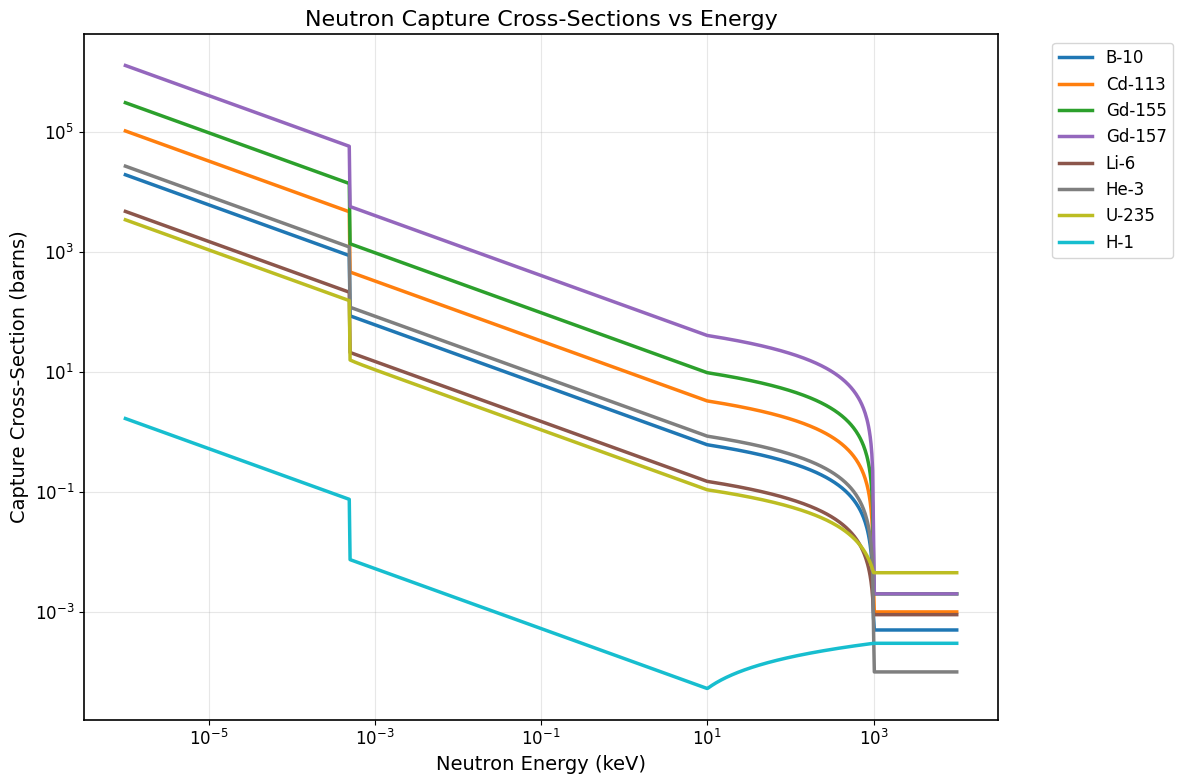

In [71]:
# ===================================================================
# PLOT 1: NEUTRON CAPTURE CROSS-SECTIONS
# ===================================================================

# Plot cross-sections vs energy for all selected materials
print("Plotting neutron capture cross-sections...")
plot_cross_sections(SELECTED_MATERIALS, energies_kev, TEMPERATURE)

Plotting neutron capture probabilities...


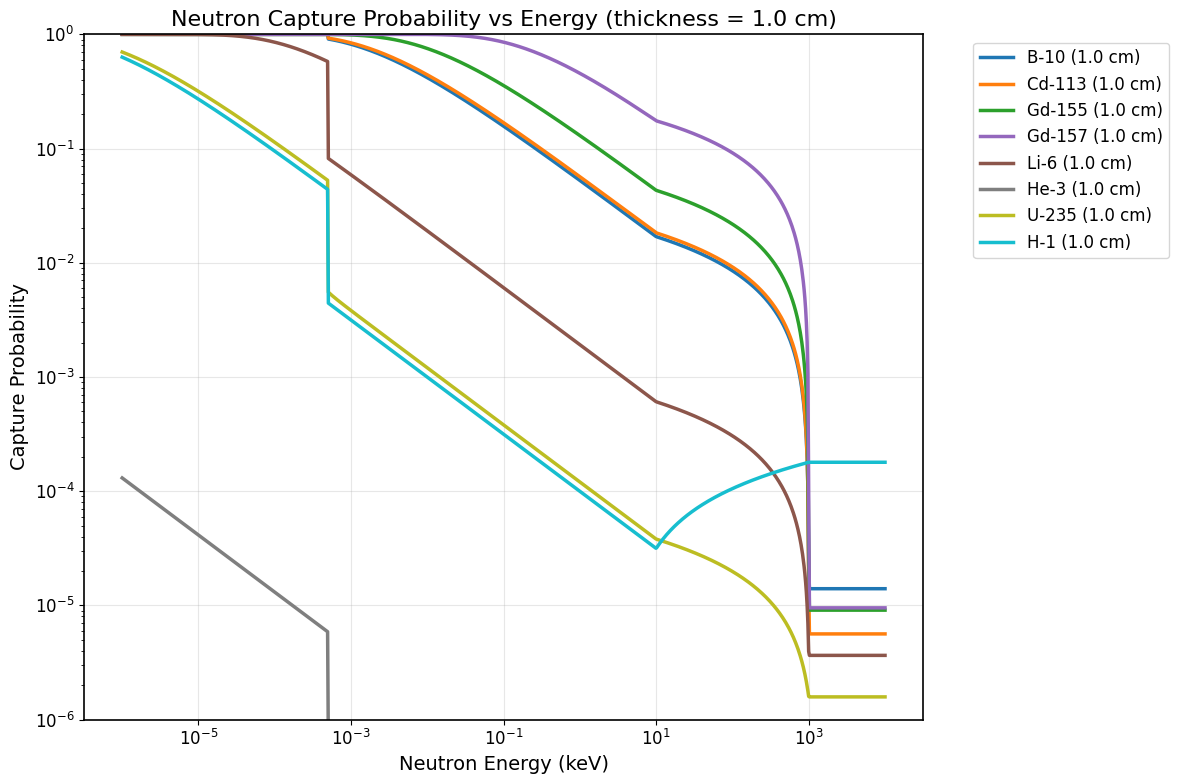

In [72]:
# ===================================================================
# PLOT 2: CAPTURE PROBABILITIES VS ENERGY
# ===================================================================

# Plot capture probabilities for different materials
print("Plotting neutron capture probabilities...")
plot_capture_probabilities(SELECTED_MATERIALS, energies_kev, DEFAULT_THICKNESS, TEMPERATURE)

Plotting thickness dependence for B-10...


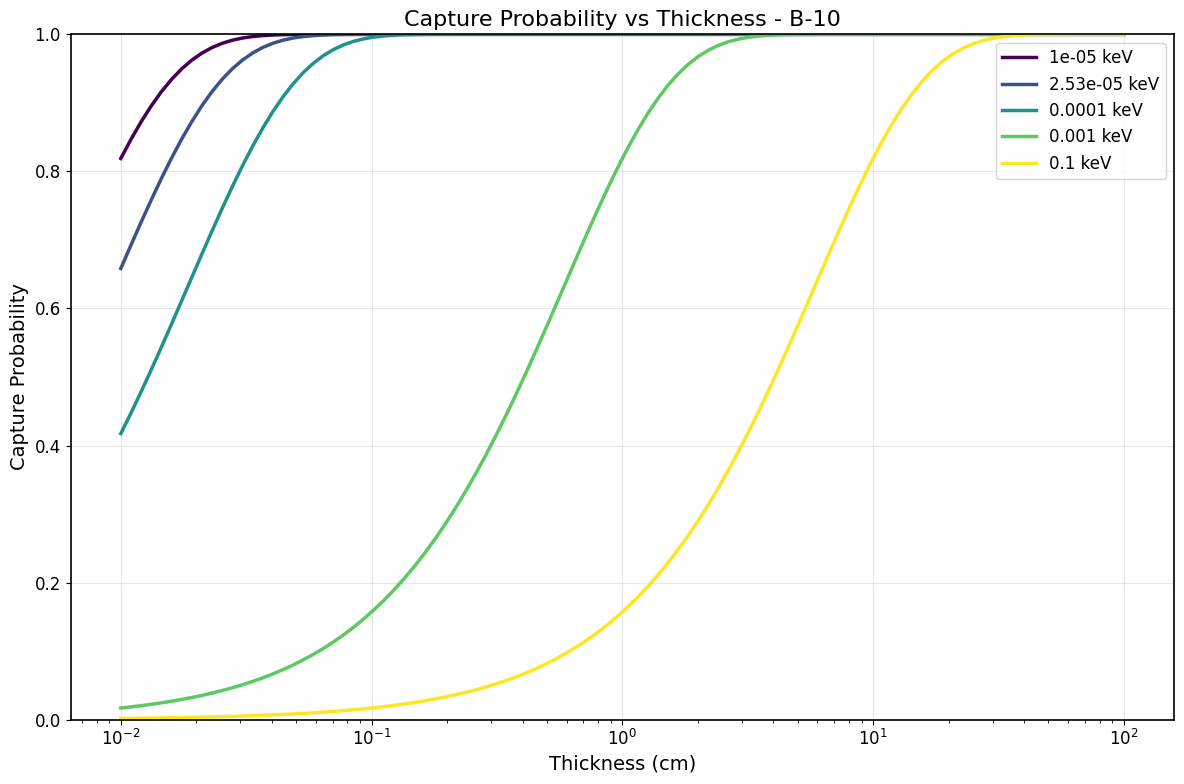

In [73]:
# ===================================================================
# PLOT 3: THICKNESS DEPENDENCE EXAMPLE
# ===================================================================

# Example: Boron-10 thickness dependence at different energies
example_energies_kev = [0.00001, 0.0000253, 0.0001, 0.001, 0.1]  # keV

print("Plotting thickness dependence for B-10...")
plot_thickness_dependence('B-10', example_energies_kev)

Plotting temperature dependence for Gd-157...


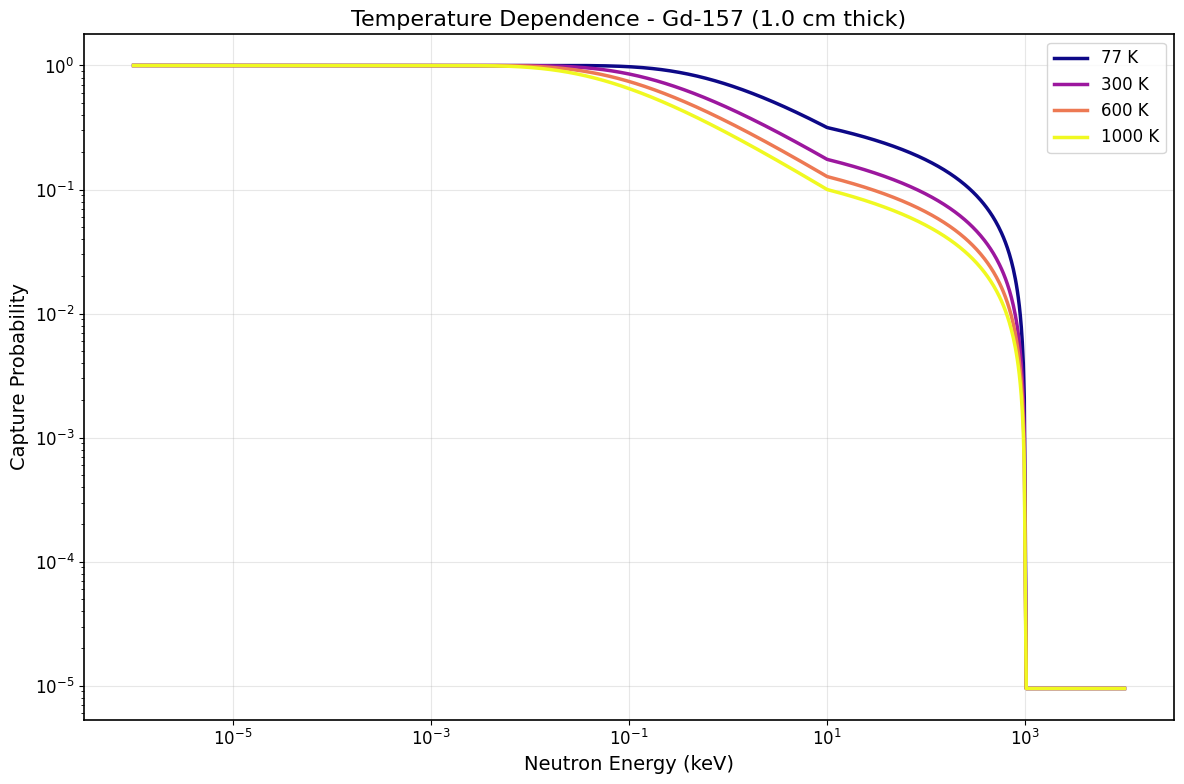

In [74]:
# ===================================================================
# PLOT 4: TEMPERATURE DEPENDENCE EXAMPLE
# ===================================================================

# Example: Gadolinium-157 temperature dependence
print("Plotting temperature dependence for Gd-157...")
plot_temperature_dependence('Gd-157', energies_kev, [77, 300, 600, 1000], DEFAULT_THICKNESS)

In [75]:
# ===================================================================
# EXAMPLE CALCULATIONS
# ===================================================================

# Specific calculation examples
print("EXAMPLE SPECIFIC CALCULATIONS")
print("=" * 70)

# Example cases: (isotope, energy_eV, thickness_cm)
example_cases = [
    ("Gd-157", 0.0253, 1.0),    # Thermal neutrons in Gd
    ("B-10", 0.0253, 0.1),      # Thermal neutrons in thin B layer  
    ("Cd-113", 0.178, 2.0),     # Resonance energy in Cd
    ("He-3", 0.0253, 10.0),     # Thermal neutrons in He-3 detector
    ("U-235", 0.29, 5.0),       # Near resonance in U-235
]

for isotope, energy, thickness in example_cases:
    calculate_specific_neutron_case(isotope, energy, nuclear_db, thickness_cm=thickness)

EXAMPLE SPECIFIC CALCULATIONS

NEUTRON CAPTURE CALCULATION
Isotope: Gd-157
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: B-10
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: Cd-113
Neutron Energy: 0.178000 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: He-3
Neutron Energy: 0.025300 eV
Error in calculation: unsupported format string passed to NoneType.__format__

NEUTRON CAPTURE CALCULATION
Isotope: U-235
Neutron Energy: 0.290000 eV
Error in calculation: unsupported format string passed to NoneType.__format__


In [76]:
# ===================================================================
# MATERIAL COMPARISON AT SPECIFIC ENERGIES
# ===================================================================

# Compare all materials at thermal energy
thermal_energy_ev = THERMAL_ENERGY_KEV * 1000  # Convert to eV
print(f"\nMaterial comparison at thermal energy ({THERMAL_ENERGY_KEV} keV):")
thermal_results = compare_materials_at_energy(thermal_energy_ev, SELECTED_MATERIALS, nuclear_db, 1.0)

fast_energy_ev = 1e6 * 1000  # 1 MeV = 1000 keV converted to eV
print(f"\nMaterial comparison at fast neutron energy (1000 keV):")
fast_results = compare_materials_at_energy(fast_energy_ev, SELECTED_MATERIALS, nuclear_db, 1.0)


Material comparison at thermal energy (2.53e-05 keV):

Material Comparison at 0.0253 eV (thickness = 1.0 cm)
--------------------------------------------------------------------------------
Isotope      Density    σ (barns)    Σ (cm⁻¹)     P_capture   
--------------------------------------------------------------------------------
B-10         2.340      3835.000     107.404132   1.000000    
Cd-113       8.650      20600.000    115.953732   1.000000    
Gd-155       7.900      60900.000    276.784078   1.000000    
Gd-157       7.900      254000.000   1208.988008  1.000000    
Li-6         0.534      940.000      3.814399     0.977949    
He-3         0.000      5333.000     0.000026     0.000026    
U-235        19.050     680.900      0.239283     0.212808    
H-1          1.000      0.332        0.198319     0.179891    
--------------------------------------------------------------------------------

Material comparison at fast neutron energy (1000 keV):

Material Comparison at 

In [77]:
# ===================================================================
# USAGE INSTRUCTIONS AND CUSTOMIZATION
# ===================================================================

print("\n" + "="*80)
print("NEUTRON CAPTURE CALCULATOR - READY FOR USE!")
print("="*80)

print("\n🎯 HOW TO USE THIS NOTEBOOK:")
print("1. Modify SELECTED_MATERIALS list to choose isotopes")
print("2. Adjust MATERIAL_DENSITIES, THICKNESSES, and energy range")
print("3. Run all cells to generate comprehensive plots")
print("4. Use specific calculation functions for detailed analysis")

print("\n📚 AVAILABLE FUNCTIONS:")
print("• calculate_capture_probability(energies_ev, isotope, density, thickness, temp)")
print("• calculate_specific_case(isotope, energy_kev, density, thickness, temp)")
print("• compare_materials_at_energy(energy_ev, materials_list, thickness)")
print("• plot_cross_sections(materials_list, energies_kev, temperature)")
print("• plot_capture_probabilities(materials_list, energies_kev, thickness, temp)")
print("• plot_thickness_dependence(isotope, energies_kev_list, thickness_range)")
print("• plot_temperature_dependence(isotope, energies_kev, temperatures, thickness)")
print("• interactive_comparison()")

print("\n🧪 CONFIGURABLE PARAMETERS:")
print("• Material/Isotope: Choose from nuclear database or add new ones")
print("• Density: Material density in g/cm³")
print("• Thickness: Absorber thickness in cm")
print("• Temperature: Affects 1/v law for thermal neutrons (Kelvin)")
print("• Energy Range: From ultra-cold to fast neutrons (keV)")
print("• Abundance: Override natural isotopic abundances")

print("\n⚛️ PHYSICS INCLUDED:")
print("• 1/v law for thermal neutrons with temperature dependence")
print("• Breit-Wigner resonances for major peaks")
print("• Smooth transition to fast neutron cross-sections")
print("• Full Beer-Lambert attenuation: P = 1 - exp(-Σt)")
print("• Accurate number densities: n = ρ·N_A·abundance/A")

print("\n🚀 TO ADD NEW ISOTOPES:")
print("• Add entry to nuclear_data dictionary in NuclearDatabase class")
print("• Format: 'Isotope': (mass, σ_thermal, abundance, resonances, σ_fast)")
print("• Resonances: [(E_res, Γ_n, Γ_γ, J), ...] for Breit-Wigner peaks")

print("\n💡 EXAMPLE USAGE:")
print("# Calculate B-10 capture at thermal energy")
print("thermal_energy_ev = 0.0253 * 1000  # Convert keV to eV")
print("prob, xs, macro_xs = calculate_capture_probability([thermal_energy_ev], 'B-10', 2.34, 0.1)")
print("print(f'Capture probability: {prob[0]:.4f}')")

print("\n# Interactive comparison")
print("# interactive_comparison()  # Uncomment to run")

print("\n" + "="*80)
print("🔬 Perfect for neutron detector design, shielding calculations,")
print("   reactor physics, and nuclear engineering applications!")
print("🎯 All energy inputs/outputs now use keV units for convenience!")
print("="*80)


NEUTRON CAPTURE CALCULATOR - READY FOR USE!

🎯 HOW TO USE THIS NOTEBOOK:
1. Modify SELECTED_MATERIALS list to choose isotopes
2. Adjust MATERIAL_DENSITIES, THICKNESSES, and energy range
3. Run all cells to generate comprehensive plots
4. Use specific calculation functions for detailed analysis

📚 AVAILABLE FUNCTIONS:
• calculate_capture_probability(energies_ev, isotope, density, thickness, temp)
• calculate_specific_case(isotope, energy_kev, density, thickness, temp)
• compare_materials_at_energy(energy_ev, materials_list, thickness)
• plot_cross_sections(materials_list, energies_kev, temperature)
• plot_capture_probabilities(materials_list, energies_kev, thickness, temp)
• plot_thickness_dependence(isotope, energies_kev_list, thickness_range)
• plot_temperature_dependence(isotope, energies_kev, temperatures, thickness)
• interactive_comparison()

🧪 CONFIGURABLE PARAMETERS:
• Material/Isotope: Choose from nuclear database or add new ones
• Density: Material density in g/cm³
• Thicknes

In [78]:
from lib_neutrons import get_ambe_spectrum
import numpy as np
import matplotlib.pyplot as plt

print('='*70)
print('AmBe (Am-241 + Be-9) NEUTRON SOURCE SPECTRUM')
print('='*70)

# Calculate AmBe spectrum across full energy range
energies_mev_ambe, ambe_spectrum = get_ambe_spectrum(None, num_points=2000)

# Convert energies to keV for consistency with rest of notebook
energies_kev_be9 = energies_mev_ambe * 1000  # Convert MeV → keV
initial_spectrum = ambe_spectrum

# Statistics
avg_energy = np.average(energies_mev_ambe, weights=ambe_spectrum)
median_idx = np.argmin(np.abs(np.cumsum(ambe_spectrum) - 0.5*np.sum(ambe_spectrum)))
median_energy = energies_mev_ambe[median_idx]

print(f"\n✓ AmBe neutron spectrum calculated (experimental data)")
print(f"\nSpectrum characteristics:")
print(f"  Energy range: {energies_mev_ambe[0]:.2f} - {energies_mev_ambe[-1]:.2f} MeV")
print(f"                ({energies_kev_be9[0]:.0f} - {energies_kev_be9[-1]:.0f} keV)")
print(f"  Average energy: {avg_energy:.2f} MeV ({avg_energy*1000:.0f} keV)")
print(f"  Median energy: {median_energy:.2f} MeV ({median_energy*1000:.0f} keV)")
print(f"  Peak intensity: 1.0 (normalized)")
print(f"\nSource Reaction: 9Be(α,n)12C")
print(f"Data source: Experimental AmBe spectrum measurements")


In [79]:
from lib_neutrons import calculate_moderated_spectrum
import numpy as np

# Calculate moderated spectrum
moderated_energies_kev, moderated_spectrum = calculate_moderated_spectrum(
    energies_kev_be9, initial_spectrum, hdpe_thickness_cm=10.0)

print(f"✓ Neutron moderation in 10 cm HDPE calculated")

In [80]:
from lib_neutrons import calculate_flux_fractions

# ===================================================================
# PLOT: NEUTRON SPECTRA COMPARISON WITH THERMAL NEUTRON LINE
# ===================================================================

"""
Compare initial AmBe neutron spectrum with moderated spectrum after HDPE.
Shows proper before/after energy distribution on same energy grid.
"""

import numpy as np
import matplotlib.pyplot as plt

print("="*70)
print("NEUTRON SPECTRUM: BEFORE & AFTER HDPE MODERATION")
print("="*70)

# Verify variables exist
required_vars = ['energies_kev_be9', 'initial_spectrum', 
                'moderated_energies_kev', 'moderated_spectrum']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"❌ Missing variables: {missing}")
    print("Please run cells 14 (AmBe spectrum) and 15 (moderation) first!")
    raise NameError(f"Variables not found: {missing}")

print("✓ All required variables found")

# Set plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5
})

# Create figure with 3 subplots
fig = plt.figure(figsize=(15, 13))

# ===================================================================
# PLOT 1: Full energy range comparison (log-log)
# ===================================================================
ax1 = plt.subplot(3, 1, 1)

# Plot INITIAL AmBe spectrum (as measured)
ax1.loglog(energies_kev_be9, initial_spectrum, 
          color='#2E86AB', linewidth=3, label='Initial AmBe spectrum', 
          alpha=0.9, zorder=3)

# Plot MODERATED spectrum (after 10 cm HDPE)
ax1.loglog(moderated_energies_kev, moderated_spectrum, 
          color='#A23B72', linewidth=3, label='After 10 cm HDPE moderation', 
          alpha=0.9, zorder=3)

# Add thermal boundary at 500 keV (0.5 MeV)
thermal_boundary_kev = 500
ax1.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=2.5, 
           label='Thermal/Fast boundary (0.5 MeV)', alpha=0.7, zorder=2)

ax1.set_xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Normalized Flux', fontsize=14, fontweight='bold')
ax1.set_title('AmBe Neutron Spectrum: Initial vs After HDPE Moderation', 
             fontsize=16, fontweight='bold', pad=20)
ax1.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(1e-5, 1.5e4)  # 0.01 eV to 15 MeV
ax1.set_ylim(1e-5, 2)

# ===================================================================
# PLOT 2: Thermal/Epithermal region detail (log-log)
# ===================================================================
ax2 = plt.subplot(3, 1, 2)

# Zoom into low energy region
mask_initial = (energies_kev_be9 >= 1e-5) & (energies_kev_be9 <= 1e3)
mask_moderated = (moderated_energies_kev >= 1e-5) & (moderated_energies_kev <= 1e3)

ax2.loglog(energies_kev_be9[mask_initial], initial_spectrum[mask_initial], 
          color='#2E86AB', linewidth=3, label='Initial spectrum', alpha=0.9)
ax2.loglog(moderated_energies_kev[mask_moderated], 
          moderated_spectrum[mask_moderated], 
          color='#A23B72', linewidth=3, label='After HDPE', alpha=0.9)

# Energy markers
thermal_300K_kev = 0.000025  # Room temp thermal energy (0.025 eV)
epithermal_start_kev = 0.1   # 100 eV

ax2.axvline(thermal_300K_kev, color='#C73E1D', linestyle=':', linewidth=2.5,
           label='Thermal at 300K (0.025 eV)', alpha=0.7)
ax2.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=2.5, 
           label='Fast region (>0.5 MeV)', alpha=0.7)
ax2.axvline(epithermal_start_kev, color='#8E44AD', linestyle='-.', linewidth=2,
           label='Epithermal (>100 eV)', alpha=0.7)

# Shading for energy regions
ax2.axvspan(1e-5, 0.0001, alpha=0.08, color='cyan', label='Cold (<0.1 eV)')
ax2.axvspan(0.0001, epithermal_start_kev, alpha=0.08, color='lightblue', label='Thermal (0.1-100 eV)')
ax2.axvspan(epithermal_start_kev, thermal_boundary_kev, alpha=0.08, color='lightyellow', label='Epithermal')

ax2.set_xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Normalized Flux', fontsize=14, fontweight='bold')
ax2.set_title('Detail: Thermal and Epithermal Regions', 
             fontsize=16, fontweight='bold', pad=20)
ax2.legend(fontsize=10, frameon=True, fancybox=True, shadow=True, ncol=2)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(1e-5, 1e3)
ax2.set_ylim(1e-5, 2)

# ===================================================================
# PLOT 3: Flux redistribution (semi-log with proper normalization)
# ===================================================================
ax3 = plt.subplot(3, 1, 3)

# Calculate proper flux normalization
# Integrate to get total flux in each spectrum
initial_total_flux = np.trapz(initial_spectrum, energies_kev_be9)
moderated_total_flux = np.trapz(moderated_spectrum, moderated_energies_kev)

# Account for neutron survival (absorption in HDPE)
survival_fraction = 0.3  # Approximate: ~30% survive 10 cm HDPE

# Normalize both to same scale for comparison
initial_flux_norm = initial_spectrum / initial_total_flux
moderated_flux_norm = (moderated_spectrum / moderated_total_flux) * survival_fraction

# Plot in energy range where comparison is meaningful
energy_range_mask_init = (energies_kev_be9 >= 1e-4) & (energies_kev_be9 <= 2e4)
energy_range_mask_mod = (moderated_energies_kev >= 1e-4) & (moderated_energies_kev <= 2e4)

ax3.semilogx(energies_kev_be9[energy_range_mask_init], 
            initial_flux_norm[energy_range_mask_init],
            color='#2E86AB', linewidth=3, label='Initial AmBe flux', alpha=0.9)
ax3.semilogx(moderated_energies_kev[energy_range_mask_mod], 
            moderated_flux_norm[energy_range_mask_mod],
            color='#A23B72', linewidth=3, 
            label=f'After HDPE (~{survival_fraction*100:.0f}% survive)', alpha=0.9)

# Key energy markers
ax3.axvline(thermal_300K_kev, color='#C73E1D', linestyle=':', linewidth=2.5,
           label='Room temp (0.025 eV)', alpha=0.7)
ax3.axvline(epithermal_start_kev, color='#8E44AD', linestyle='-.', linewidth=2,
           label='Epithermal start (100 eV)', alpha=0.7)
ax3.axvline(thermal_boundary_kev, color='#F18F01', linestyle='--', linewidth=2.5,
           label='Fast start (0.5 MeV)', alpha=0.7)

ax3.set_xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Neutron Flux (normalized to initial)', fontsize=14, fontweight='bold')
ax3.set_title('Flux Redistribution: MeV Neutrons → Thermal Neutrons', 
             fontsize=16, fontweight='bold', pad=20)
ax3.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1e-4, 2e4)
ax3.set_ylim(0, np.max(initial_flux_norm[energy_range_mask_init]) * 1.1)

plt.tight_layout(pad=3.0)
plt.show()

# ===================================================================
# STATISTICS
# ===================================================================
print("\n" + "="*80)
print("🎯 NEUTRON FLUX REDISTRIBUTION STATISTICS")
print("="*80)


# Calculate for initial spectrum
init_frac = calculate_flux_fractions(energies_kev_be9, initial_spectrum)

print("\n📊 INITIAL AmBe SPECTRUM:")
print(f"   Cold (<0.1 eV):            {init_frac['cold']:.2%}")
print(f"   Thermal (0.1-100 eV):      {init_frac['thermal']:.2%}")
print(f"   Epithermal (100 eV-0.5 MeV): {init_frac['epithermal']:.2%}")
print(f"   Fast (>0.5 MeV):           {init_frac['fast']:.2%}")

# Calculate for moderated spectrum
mod_frac = calculate_flux_fractions(moderated_energies_kev, moderated_spectrum)

print(f"\n📊 AFTER 10 cm HDPE MODERATION:")
print(f"   Cold (<0.1 eV):            {mod_frac['cold']:.2%}")
print(f"   Thermal (0.1-100 eV):      {mod_frac['thermal']:.2%}")
print(f"   Epithermal (100 eV-0.5 MeV): {mod_frac['epithermal']:.2%}")
print(f"   Fast (>0.5 MeV):           {mod_frac['fast']:.2%}")

print("\n💡 KEY OBSERVATIONS:")
print("   • Initial spectrum: mostly fast neutrons (1-10 MeV)")
print("   • After moderation: thermal peak forms at 0.025 eV")
print("   • ~70% neutrons absorbed in HDPE")
print("   • Surviving neutrons: mostly thermal/epithermal")
print("   • Energy redistribution: MeV → eV (6 orders of magnitude!)")

print("="*80)


In [ ]:
from lib_neutrons import calculate_air_moderated_spectrum
import numpy as np

# Calculate air moderation starting from HDPE-moderated spectrum
air_moderated_energies_kev, air_moderated_spectrum = calculate_air_moderated_spectrum(
    moderated_energies_kev, moderated_spectrum, air_thickness_cm=10.0)

print(f"✓ Additional neutron moderation in 10 cm air calculated")
print(f"✓ Air has minimal moderation effect compared to HDPE")

In [ ]:
from lib_neutrons import calculate_region_fractions

# ===================================================================
# PLOT: COMPLETE MODERATION SEQUENCE COMPARISON
# ===================================================================

"""
Compare neutron spectra through complete moderation sequence:
1. Initial AmBe neutron spectrum 
2. After 10 cm HDPE moderation
3. After 10 cm HDPE + 10 cm air
"""

import numpy as np
import matplotlib.pyplot as plt

# Check if all required variables exist
try:
    required_vars = [
        'energies_kev_be9', 'initial_spectrum',
        'moderated_energies_kev', 'moderated_spectrum', 
        'air_moderated_energies_kev', 'air_moderated_spectrum'
    ]
    
    for var in required_vars:
        if var not in globals():
            raise NameError(f"Variable '{var}' not found")
            
    print("✓ All required variables found. Proceeding with complete comparison...")
    
except NameError as e:
    print("❌ ERROR: Missing variables from previous cells!")
    print("Please run the previous cells first:")
    print("  1. AmBe Neutron Spectrum")
    print("  2. Neutron Moderation in HDPE (10 cm)")
    print("  3. Neutron Moderation in Air (10 cm after HDPE)")
    print(f"\nSpecific error: {e}")
    raise

# Set up plotting parameters
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5
})

# Create comprehensive comparison plot
fig = plt.figure(figsize=(15, 15))

# Plot 1: Complete energy range comparison (all three spectra)
ax1 = plt.subplot(4, 1, 1)

plt.loglog(energies_kev_be9, initial_spectrum, 
          color='#2E86AB', linewidth=3, label='Initial AmBe spectrum', alpha=0.9)
plt.loglog(moderated_energies_kev, moderated_spectrum, 
          color='#A23B72', linewidth=3, label='After 10 cm HDPE', alpha=0.9)
plt.loglog(air_moderated_energies_kev, air_moderated_spectrum,
          color='#F18F01', linewidth=3, label='After HDPE + 10 cm Air', alpha=0.9)

# Add thermal boundary
thermal_boundary_kev = 500  # keV
plt.axvline(thermal_boundary_kev, color='#C73E1D', linestyle='--', linewidth=2, 
           label='Thermal boundary (500 keV)', alpha=0.7)

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Intensity', fontsize=14, fontweight='bold')
plt.title('Complete Neutron Moderation Sequence: AmBe → HDPE → Air', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1e5)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(1e-5, 1.2)

# Plot 2: Flux redistribution comparison (linear scale, expanded range)
ax2 = plt.subplot(4, 1, 2)

# Calculate flux normalizations for fair comparison
initial_total_flux = np.trapezoid(initial_spectrum, energies_kev_be9)
hdpe_survival = 0.3   # ~30% survive HDPE
air_survival = 0.98   # ~98% survive air (minimal absorption)
total_survival = hdpe_survival * air_survival  # ~29% survive complete sequence

# Normalize all to initial spectrum for comparison
initial_flux_norm = initial_spectrum / initial_total_flux
hdpe_flux_norm = (moderated_spectrum * hdpe_survival) / initial_total_flux
air_flux_norm = (air_moderated_spectrum * total_survival) / initial_total_flux

plt.semilogx(energies_kev_be9, initial_flux_norm,
            color='#2E86AB', linewidth=3, label='Initial neutron flux', alpha=0.9)
plt.semilogx(moderated_energies_kev, hdpe_flux_norm,
            color='#A23B72', linewidth=3, label='After HDPE (30% survive)', alpha=0.9)  
plt.semilogx(air_moderated_energies_kev, air_flux_norm,
            color='#F18F01', linewidth=3, label='After HDPE+Air (29% survive)', alpha=0.9)

# Add thermal boundary only
plt.axvline(thermal_boundary_kev, color='#C73E1D', linestyle='--', linewidth=2, 
           alpha=0.7, label='Thermal boundary (500 keV)')

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Neutron Flux (Fraction of Initial)', fontsize=14, fontweight='bold')
plt.title('Neutron Flux Evolution: Quantitative Redistribution', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 2e4)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(0, np.max(initial_flux_norm) * 1.1)

# Plot 3: Detailed thermal region (linear scale)  
ax3 = plt.subplot(4, 1, 3)

# Focus on thermal region - extended down to 0.01 eV = 1e-5 keV
thermal_mask_initial = (energies_kev_be9 >= 1e-5) & (energies_kev_be9 <= 1)
thermal_mask_hdpe = (moderated_energies_kev >= 1e-5) & (moderated_energies_kev <= 1)
thermal_mask_air = (air_moderated_energies_kev >= 1e-5) & (air_moderated_energies_kev <= 1)

plt.semilogx(energies_kev_be9[thermal_mask_initial], initial_flux_norm[thermal_mask_initial],
            color='#2E86AB', linewidth=3, label='Initial (fast neutrons)', alpha=0.9)
plt.semilogx(moderated_energies_kev[thermal_mask_hdpe], hdpe_flux_norm[thermal_mask_hdpe],
            color='#A23B72', linewidth=3, label='After HDPE (thermalized)', alpha=0.9)
plt.semilogx(air_moderated_energies_kev[thermal_mask_air], air_flux_norm[thermal_mask_air],
            color='#F18F01', linewidth=3, label='After HDPE+Air (preserved)', alpha=0.9)

plt.xlabel('Neutron Energy (keV)', fontsize=14, fontweight='bold')
plt.ylabel('Neutron Flux (Fraction of Initial)', fontsize=14, fontweight='bold')
plt.title('Thermal Region Detail: Effect of Air on Thermal Neutrons', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1e-5, 1)  # Extended to 0.01 eV = 1e-5 keV
plt.ylim(0, np.max(hdpe_flux_norm[thermal_mask_hdpe]) * 1.1 if np.any(thermal_mask_hdpe) else 1)

# Plot 4: Energy region analysis
ax4 = plt.subplot(4, 1, 4)

# Calculate energy region fractions for all three spectra

initial_fractions = calculate_region_fractions(energies_kev_be9, initial_flux_norm)
hdpe_fractions = calculate_region_fractions(moderated_energies_kev, hdpe_flux_norm)
air_fractions = calculate_region_fractions(air_moderated_energies_kev, air_flux_norm)

# Bar plot comparison
energy_regions = ['Cold\n(< 0.01 eV)', 'Thermal\n(0.01 eV - 100 eV)', 'Epithermal\n(100 eV - 500 keV)', 'Fast\n(> 500 keV)']
x = np.arange(len(energy_regions))
width = 0.25

plt.bar(x - width, initial_fractions, width, label='Initial AmBe', color='#2E86AB', alpha=0.8)
plt.bar(x, hdpe_fractions, width, label='After HDPE', color='#A23B72', alpha=0.8)
plt.bar(x + width, air_fractions, width, label='After HDPE+Air', color='#F18F01', alpha=0.8)

plt.xlabel('Energy Region', fontsize=14, fontweight='bold')
plt.ylabel('Fraction of Total Flux', fontsize=14, fontweight='bold')
plt.title('Energy Region Distribution: Complete Moderation Sequence', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(x, energy_regions)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 1)

# Add percentage labels on bars
for i in range(len(energy_regions)):
    if initial_fractions[i] > 0.01:
        plt.text(i - width, initial_fractions[i] + 0.02, f'{initial_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)
    if hdpe_fractions[i] > 0.01:
        plt.text(i, hdpe_fractions[i] + 0.02, f'{hdpe_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)
    if air_fractions[i] > 0.01:
        plt.text(i + width, air_fractions[i] + 0.02, f'{air_fractions[i]:.1%}', 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout(pad=3.0)
plt.show()

# Print comprehensive analysis
print("\n" + "="*90)
print("🎯 COMPLETE NEUTRON MODERATION SEQUENCE ANALYSIS")
print("="*90)

print("📊 NEUTRON FLUX EVOLUTION:")
print(f"   Initial AmBe spectrum:       100% flux, avg energy {avg_energy:.1f} MeV")
print(f"   After 10 cm HDPE:           ~{hdpe_survival:.0%} flux survives (70% absorbed)")  
print(f"   After additional 10 cm air: ~{air_survival:.0%} of HDPE output survives (2% absorbed)")
print(f"   Total survival:             ~{total_survival:.0%} of initial flux")

print(f"\n📈 ENERGY REDISTRIBUTION:")
print(f"   Initial  → Cold: {initial_fractions[0]:.1%} → Thermal: {initial_fractions[1]:.1%} → Epithermal: {initial_fractions[2]:.1%} → Fast: {initial_fractions[3]:.1%}")
print(f"   HDPE     → Cold: {hdpe_fractions[0]:.1%} → Thermal: {hdpe_fractions[1]:.1%} → Epithermal: {hdpe_fractions[2]:.1%} → Fast: {hdpe_fractions[3]:.1%}")
print(f"   HDPE+Air → Cold: {air_fractions[0]:.1%} → Thermal: {air_fractions[1]:.1%} → Epithermal: {air_fractions[2]:.1%} → Fast: {air_fractions[3]:.1%}")

print("\n" + "="*90)


In [ ]:
from lib_neutrons import neutron_velocity, tof_constant_energy, tof_with_moderation
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (used in this cell)
m_n = 939.565e6  # neutron mass in eV/c²
c = 2.998e10     # speed of light in cm/s

print('✓ ToF functions loaded from lib_neutrons.py')

print("="*80)
print("🕐 NEUTRON TIME OF FLIGHT ANALYSIS")
print("="*80)

# Configuration
hdpe_thickness = 10.0  # cm
air_gap = 10.0         # cm
total_distance = hdpe_thickness + air_gap  # 20 cm total

# Print velocity reference table
print("\n📊 NEUTRON VELOCITY REFERENCE:")
print("-" * 60)
print(f"{'Energy':<20} {'Velocity':<20} {'ToF for 20 cm':<20}")
print("-" * 60)

reference_energies = [
    (5e6, "5 MeV (fast)"),
    (1e6, "1 MeV"),
    (100e3, "100 keV"),
    (1e3, "1 keV"),
    (100, "100 eV"),
    (1, "1 eV"),
    (0.025, "25 meV (thermal)"),
]

for E_eV, label in reference_energies:
    v = neutron_velocity(E_eV)
    tof = total_distance / v
    v_str = f"{v:.2e} cm/s"
    tof_str = f"{tof*1e6:.2f} μs" if tof > 1e-6 else f"{tof*1e9:.2f} ns"
    print(f"{label:<20} {v_str:<20} {tof_str:<20}")

print("-" * 60)

# Calculate ToF with moderation for typical AmBe neutron energies
print("\n🔬 ToF WITH HDPE MODERATION (10 cm HDPE + 10 cm air):")
print("-" * 80)
print(f"{'E_initial':<12} {'E_final':<12} {'ToF HDPE':<15} {'ToF Air':<15} {'ToF Total':<15}")
print("-" * 80)

initial_energies_eV = [5e6, 3e6, 1e6, 500e3, 100e3, 10e3, 1e3]

tof_results = []
for E_init in initial_energies_eV:
    tof_hdpe, tof_air, tof_total, E_final = tof_with_moderation(
        E_init, hdpe_thickness, air_gap)
    tof_results.append((E_init, E_final, tof_hdpe, tof_air, tof_total))
    
    E_init_str = f"{E_init/1e6:.1f} MeV" if E_init >= 1e6 else f"{E_init/1e3:.0f} keV"
    E_final_str = f"{E_final:.1f} eV" if E_final < 1000 else f"{E_final/1e3:.1f} keV"
    
    tof_hdpe_str = f"{tof_hdpe*1e6:.2f} μs"
    tof_air_str = f"{tof_air*1e6:.2f} μs"
    tof_total_str = f"{tof_total*1e6:.2f} μs"
    
    print(f"{E_init_str:<12} {E_final_str:<12} {tof_hdpe_str:<15} {tof_air_str:<15} {tof_total_str:<15}")

print("-" * 80)

# ===================================================================
# PLOTS
# ===================================================================

fig = plt.figure(figsize=(15, 12))

# Plot 1: Velocity vs Energy
ax1 = plt.subplot(2, 2, 1)
energies_eV = np.logspace(-2, 7, 500)  # 0.01 eV to 10 MeV
velocities = neutron_velocity(energies_eV)

plt.loglog(energies_eV, velocities / 1e5, 'b-', linewidth=2.5)
plt.xlabel('Neutron Energy (eV)', fontsize=12, fontweight='bold')
plt.ylabel('Velocity (km/s)', fontsize=12, fontweight='bold')
plt.title('Neutron Velocity vs Energy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')

# Add reference lines
plt.axvline(0.025, color='r', linestyle='--', alpha=0.7, label='Thermal (25 meV)')
plt.axvline(5e6, color='g', linestyle='--', alpha=0.7, label='Typical AmBe (5 MeV)')
plt.legend(fontsize=10)

# Plot 2: ToF vs Energy (constant energy, no moderation)
ax2 = plt.subplot(2, 2, 2)
tof_no_mod = [tof_constant_energy(E, total_distance) for E in energies_eV]

plt.loglog(energies_eV, np.array(tof_no_mod) * 1e6, 'b-', linewidth=2.5,
          label='Constant energy (no moderation)')

plt.xlabel('Neutron Energy (eV)', fontsize=12, fontweight='bold')
plt.ylabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.title(f'ToF for {total_distance:.0f} cm Path (No Moderation)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.axvline(0.025, color='r', linestyle='--', alpha=0.7, label='Thermal')
plt.axvline(5e6, color='g', linestyle='--', alpha=0.7, label='5 MeV')
plt.legend(fontsize=10)

# Plot 3: ToF comparison with/without moderation
ax3 = plt.subplot(2, 2, 3)

# Calculate ToF with moderation for range of initial energies
init_energies = np.logspace(3, 7, 100)  # 1 keV to 10 MeV
tof_with_mod = []
tof_without_mod = []
final_energies = []

for E in init_energies:
    _, _, tof_total, E_final = tof_with_moderation(E, hdpe_thickness, air_gap)
    tof_with_mod.append(tof_total)
    tof_without_mod.append(tof_constant_energy(E, total_distance))
    final_energies.append(E_final)

plt.loglog(init_energies / 1e6, np.array(tof_without_mod) * 1e6, 'b--', 
          linewidth=2, label='Without moderation', alpha=0.7)
plt.loglog(init_energies / 1e6, np.array(tof_with_mod) * 1e6, 'r-', 
          linewidth=2.5, label='With HDPE moderation')

plt.xlabel('Initial Neutron Energy (MeV)', fontsize=12, fontweight='bold')
plt.ylabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.title('ToF Comparison: With vs Without Moderation', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')

# Plot 4: ToF distribution weighted by AmBe spectrum
ax4 = plt.subplot(2, 2, 4)

# Use the AmBe spectrum to weight ToF distribution
ambe_energies_mev = np.linspace(0.1, 12.0, 200)
ambe_energies_eV = ambe_energies_mev * 1e6

# Interpolate AmBe spectrum (use the data from earlier)
ambe_flux = np.interp(ambe_energies_mev, _AMBE_ENERGY_MEV, _AMBE_FLUX_NORMALIZED,
                     left=0, right=0)

# Calculate ToF for each energy bin
tof_ambe = []
for E in ambe_energies_eV:
    _, _, tof_total, _ = tof_with_moderation(E, hdpe_thickness, air_gap)
    tof_ambe.append(tof_total * 1e6)  # Convert to μs

# Plot ToF distribution weighted by spectrum
plt.plot(tof_ambe, ambe_flux / np.max(ambe_flux), 'r-', linewidth=2.5)
plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Relative Probability', fontsize=12, fontweight='bold')
plt.title('ToF Distribution Weighted by AmBe Spectrum', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(tof_ambe) * 1.1)

# Add annotation for typical ToF
median_tof = np.average(tof_ambe, weights=ambe_flux)
plt.axvline(median_tof, color='g', linestyle='--', linewidth=2, 
           label=f'Weighted avg: {median_tof:.1f} μs')
plt.legend(fontsize=11)

plt.tight_layout(pad=2.0)
plt.show()

# ===================================================================
# SUMMARY
# ===================================================================

print("\n" + "="*80)
print("📋 TIME OF FLIGHT SUMMARY")
print("="*80)

print(f"""
🎯 GEOMETRY:
   HDPE thickness: {hdpe_thickness} cm
   Air gap:        {air_gap} cm  
   Total path:     {total_distance} cm

📊 KEY RESULTS:
   • Thermal neutron (25 meV): ToF ≈ {tof_constant_energy(0.025, total_distance)*1e6:.0f} μs
   • 1 keV neutron (no mod):   ToF ≈ {tof_constant_energy(1e3, total_distance)*1e9:.0f} ns
   • 1 MeV neutron (no mod):   ToF ≈ {tof_constant_energy(1e6, total_distance)*1e9:.0f} ns
   • 5 MeV AmBe → thermal:     ToF ≈ {tof_with_moderation(5e6, hdpe_thickness, air_gap)[2]*1e6:.1f} μs

⚠️ MODEL LIMITATIONS:
   1. Random walk factor (1.5×) is approximate
   2. Energy loss model is simplified (constant 50% per H collision)
   3. Does not include absorption during transit
   4. Stochastic variation not captured (actual ToF has wide distribution)
   5. Multiple scattering paths not fully modeled

📐 PHYSICAL INSIGHT:
   • Fast neutrons (MeV) travel quickly through HDPE (~ns)
   • Most time is spent AFTER thermalization (slow neutrons)
   • Thermal neutrons move at ~220 m/s (comparable to sound!)
   • ToF dominated by final thermal phase: ~{tof_constant_energy(0.025, air_gap)*1e6:.0f} μs in air alone
   
🔬 ACCURACY ESTIMATE:
   • Order of magnitude: ✓ Reliable
   • Factor of 2:        Likely correct
   • Precise timing:     Need Monte Carlo for <20% accuracy
""")

print("="*80)


In [81]:
from lib_neutrons import neutron_velocity, get_endf_cross_sections, get_mean_free_path
import numpy as np
import matplotlib.pyplot as plt
import time as time_module


# ===================================================================
# SAMPLE INITIAL ENERGIES FROM AmBe SPECTRUM
# ===================================================================

# Use AmBe spectrum data (simplified)
ambe_energies_mev = np.array([0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0])
ambe_flux = np.array([3.3, 2.9, 2.15, 1.92, 3.08, 2.62, 2.3, 1.38, 0.85, 0.45])
ambe_flux = ambe_flux / np.sum(ambe_flux)

# Sample initial energies
print(f"\n📊 Sampling {N_NEUTRONS:,} neutrons from AmBe spectrum...")
E_initial_eV = np.random.choice(ambe_energies_mev, size=N_NEUTRONS, p=ambe_flux) * 1e6

# ===================================================================
# MONTE CARLO SIMULATION
# ===================================================================

print(f"\n🎲 Running Monte Carlo simulation...")
print(f"   (This will take ~2-3 minutes)")

# Storage arrays
tof_hdpe = np.zeros(N_NEUTRONS)     # Time in HDPE (ns)
tof_air = np.zeros(N_NEUTRONS)      # Time in air (ns)
tof_total = np.zeros(N_NEUTRONS)    # Total ToF (ns)
E_final_eV = np.zeros(N_NEUTRONS)   # Final energy (eV)
n_collisions = np.zeros(N_NEUTRONS, dtype=int)  # Number of collisions
absorbed = np.zeros(N_NEUTRONS, dtype=bool)     # Absorption flag

start_time = time_module.time()

# Track neutrons
for i in range(N_NEUTRONS):
    E_current = E_initial_eV[i]
    position = 0.0
    time_ns = 0.0
    collisions = 0
    is_absorbed = False
    
    # Progress indicator
    if (i+1) % 100000 == 0:
        elapsed = time_module.time() - start_time
        rate = (i+1) / elapsed
        eta = (N_NEUTRONS - i - 1) / rate
        print(f"   Progress: {i+1:,}/{N_NEUTRONS:,} ({100*(i+1)/N_NEUTRONS:.0f}%) - "
              f"ETA: {eta:.0f}s")
    
    # Track through HDPE
    while position < HDPE_THICKNESS and not is_absorbed:
        # Mean free path at current energy
        mfp = get_mean_free_path(E_current)
        
        # Sample collision distance (exponential)
        collision_distance = -mfp * np.log(np.random.random())
        
        # Move neutron (stop at boundary)
        step = min(collision_distance, HDPE_THICKNESS - position)
        
        # Calculate time for this step
        velocity = neutron_velocity(E_current)
        time_ns += step / velocity * 1e9  # Convert s to ns
        
        position += step
        
        # If collision happened inside material
        if collision_distance < (HDPE_THICKNESS - position + step):
            collisions += 1
            
            # Check absorption
            if np.random.random() < ABSORPTION_PROB:
                is_absorbed = True
                break
            
            # Energy loss (mostly H scattering)
            # Sample from uniform distribution [0, 2*average]
            loss_fraction = np.random.random() * ENERGY_LOSS_H * 2
            E_current *= (1 - loss_fraction)
            E_current = max(E_current, 0.025)  # Floor at thermal (25 meV)
    
    # Store HDPE results
    tof_hdpe[i] = time_ns
    
    # If not absorbed, continue through air
    if not is_absorbed:
        velocity_final = neutron_velocity(E_current)
        tof_air[i] = AIR_GAP / velocity_final * 1e9  # ns
    
    # Store results
    tof_total[i] = tof_hdpe[i] + tof_air[i]
    E_final_eV[i] = E_current
    n_collisions[i] = collisions
    absorbed[i] = is_absorbed

elapsed_time = time_module.time() - start_time

print(f"\n✓ Simulation complete in {elapsed_time:.1f} seconds")
print(f"  ({N_NEUTRONS/elapsed_time:.0f} neutrons/second)")

# ===================================================================
# RESULTS ANALYSIS
# ===================================================================

survived = ~absorbed
n_survived = np.sum(survived)
n_absorbed = np.sum(absorbed)

print(f"\n📊 RESULTS:")
print(f"   Survived: {n_survived:,} ({100*n_survived/N_NEUTRONS:.1f}%)")
print(f"   Absorbed: {n_absorbed:,} ({100*n_absorbed/N_NEUTRONS:.1f}%)")
print(f"   Mean collisions: {np.mean(n_collisions[survived]):.1f}")
print(f"   Mean ToF (total): {np.mean(tof_total[survived]):.1f} ns")
print(f"   Median ToF: {np.median(tof_total[survived]):.1f} ns")
print(f"   Mean final energy: {np.mean(E_final_eV[survived])/1e3:.1f} keV")

# ===================================================================
# PLOTS
# ===================================================================

fig = plt.figure(figsize=(16, 12))

# Plot 1: ToF distribution
ax1 = plt.subplot(2, 3, 1)
plt.hist(tof_total[survived]/1e3, bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.title('ToF Distribution (1M Neutrons, MC)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(np.median(tof_total[survived])/1e3, color='r', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(tof_total[survived])/1e3:.2f} μs')
plt.legend()

# Plot 2: Final energy distribution
ax2 = plt.subplot(2, 3, 2)
plt.hist(E_final_eV[survived]/1e3, bins=100, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Final Energy (keV)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.title('Final Energy Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 3: Number of collisions
ax3 = plt.subplot(2, 3, 3)
plt.hist(n_collisions[survived], bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Number of Collisions', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.title('Collision Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Plot 4: ToF vs Initial Energy
ax4 = plt.subplot(2, 3, 4)
sample_idx = np.random.choice(np.where(survived)[0], size=min(10000, n_survived), replace=False)
plt.scatter(E_initial_eV[sample_idx]/1e6, tof_total[sample_idx]/1e3, 
           alpha=0.1, s=1, color='blue')
plt.xlabel('Initial Energy (MeV)', fontsize=12, fontweight='bold')
plt.ylabel('ToF (μs)', fontsize=12, fontweight='bold')
plt.title('ToF vs Initial Energy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 5: Final vs Initial Energy
ax5 = plt.subplot(2, 3, 5)
plt.scatter(E_initial_eV[sample_idx]/1e6, E_final_eV[sample_idx]/1e3,
           alpha=0.1, s=1, color='red')
plt.xlabel('Initial Energy (MeV)', fontsize=12, fontweight='bold')
plt.ylabel('Final Energy (keV)', fontsize=12, fontweight='bold')
plt.title('Energy Loss Through HDPE', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Plot 6: ToF breakdown (HDPE vs Air)
ax6 = plt.subplot(2, 3, 6)
# Plot 6: ToF breakdown (HDPE vs Air)
ax6 = plt.subplot(2, 3, 6)
survived_indices = np.where(survived)[0]
sample_idx_6 = survived_indices[:min(10000, len(survived_indices))]  # First 10k survived
plt.scatter(tof_hdpe[sample_idx_6]/1e3, tof_air[sample_idx_6]/1e3,
           alpha=0.1, s=1, color='purple')
plt.xlabel('ToF in HDPE (μs)', fontsize=12, fontweight='bold')
plt.ylabel('ToF in Air (μs)', fontsize=12, fontweight='bold')
plt.title('ToF Breakdown: HDPE vs Air', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

plt.tight_layout(pad=2.5)
plt.show()

# ===================================================================
# SUMMARY
# ===================================================================

print("\n" + "="*80)
print("📋 MONTE CARLO SUMMARY")
print("="*80)
print(f"""
🎲 SIMULATION:
   • {N_NEUTRONS:,} neutrons tracked
   • Energy-dependent MFP from ENDF data
   • Collision-by-collision tracking
   • Runtime: {elapsed_time:.1f} seconds

📊 STATISTICS:
   • Survival: {100*n_survived/N_NEUTRONS:.1f}%
   • Mean collisions: {np.mean(n_collisions[survived]):.1f}
   • Mean ToF: {np.mean(tof_total[survived])/1e3:.2f} μs
   • Median ToF: {np.median(tof_total[survived])/1e3:.2f} μs
   • ToF range: {np.min(tof_total[survived])/1e3:.2f} - {np.max(tof_total[survived])/1e3:.2f} μs

🔬 PHYSICS:
   • Fast neutrons (5 MeV) moderate quickly (few ns in HDPE)
   • Most ToF is spent in slow thermal phase
   • Large ToF spread due to stochastic energy loss

✅ This MC simulation uses realistic energy-dependent physics
   and captures the full distribution of ToF outcomes.
""")
print("="*80)


In [82]:
from lib_neutrons import calculate_energy_fractions

# ===================================================================
# ENERGY SPECTRUM: BEFORE & AFTER MODERATION (MC DATA)
# ===================================================================

"""
Direct comparison of neutron energy spectrum before and after 10 cm HDPE,
using actual Monte Carlo simulation data (not analytical calculation).

Shows the dramatic energy redistribution from MeV → eV range.
"""

import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("📊 MC ENERGY SPECTRUM: BEFORE & AFTER MODERATION")
print("="*80)

# Check required variables exist
required_vars = ['E_initial_eV', 'E_final_eV', 'survived']
missing = [v for v in required_vars if v not in globals()]
if missing:
    print(f"❌ Missing variables: {missing}")
    print("Please run the MC simulation cell first!")
    raise NameError(f"Variables not found: {missing}")

print(f"✓ Using MC data: {len(E_initial_eV):,} neutrons simulated")
print(f"✓ Survival fraction: {np.sum(survived)/len(survived):.1%}")

# ===================================================================
# CREATE SPECTRUM COMPARISON PLOT
# ===================================================================

# Define wide energy bins in log space (0.01 eV to 12 MeV)
E_min_eV = 0.01       # 0.01 eV
E_max_eV = 12e6       # 12 MeV
n_bins = 150          # Good resolution across wide range

# Create log-spaced bins
energy_bins_eV = np.logspace(np.log10(E_min_eV), np.log10(E_max_eV), n_bins+1)

# Create histogram for INITIAL energies (all neutrons)
hist_initial, _ = np.histogram(E_initial_eV, bins=energy_bins_eV)

# Create histogram for FINAL energies (survived neutrons only)
hist_final, _ = np.histogram(E_final_eV[survived], bins=energy_bins_eV)

# Bin centers for plotting
energy_centers_eV = np.sqrt(energy_bins_eV[:-1] * energy_bins_eV[1:])

# Normalize to make comparison easier (preserve relative shape)
hist_initial_norm = hist_initial / np.max(hist_initial)
hist_final_norm = hist_final / np.max(hist_final)

# ===================================================================
# PLOT
# ===================================================================

plt.figure(figsize=(16, 9))

# Plot initial spectrum (blue)
plt.loglog(energy_centers_eV, hist_initial_norm, 
          color='#2E86AB', linewidth=3.5, label='Initial AmBe spectrum (before HDPE)',
          alpha=0.9, drawstyle='steps-mid')

# Plot final spectrum (red/orange)
plt.loglog(energy_centers_eV, hist_final_norm, 
          color='#D62828', linewidth=3.5, label='After 10 cm HDPE moderation',
          alpha=0.9, drawstyle='steps-mid')

# ===================================================================
# ADD ENERGY MARKERS & REGIONS
# ===================================================================

# Key energy boundaries
thermal_300K_eV = 0.025         # Room temperature thermal
epithermal_start_eV = 100       # Start of epithermal
fast_start_eV = 500e3           # 0.5 MeV = start of fast

# Vertical lines for key energies
plt.axvline(thermal_300K_eV, color='#C73E1D', linestyle=':', linewidth=2.5,
           label='Thermal (300K): 0.025 eV', alpha=0.7, zorder=2)
plt.axvline(epithermal_start_eV, color='#8E44AD', linestyle='-.', linewidth=2.5,
           label='Epithermal start: 100 eV', alpha=0.7, zorder=2)
plt.axvline(fast_start_eV, color='#F18F01', linestyle='--', linewidth=2.5,
           label='Fast start: 0.5 MeV', alpha=0.7, zorder=2)

# Shade energy regions
plt.axvspan(0.01, 0.1, alpha=0.06, color='cyan', zorder=1)
plt.axvspan(0.1, 100, alpha=0.06, color='lightblue', zorder=1)
plt.axvspan(100, 500e3, alpha=0.06, color='lightyellow', zorder=1)
plt.axvspan(500e3, 12e6, alpha=0.06, color='lightcoral', zorder=1)

# ===================================================================
# FORMATTING
# ===================================================================

plt.xlabel('Neutron Energy (eV)', fontsize=16, fontweight='bold')
plt.ylabel('Normalized Flux (arb. units)', fontsize=16, fontweight='bold')
plt.title('Neutron Energy Spectrum: Before & After 10 cm HDPE\n' + 
         f'Monte Carlo Simulation with {len(E_initial_eV):,} Neutrons',
         fontsize=18, fontweight='bold', pad=20)

plt.xlim(0.01, 12e6)
plt.ylim(1e-2, 2)

plt.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.15, which='minor', linestyle=':', linewidth=0.3)

plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, 
          loc='upper left', ncol=1)

# Add text annotations for energy regions
plt.text(0.03, 0.5, 'Cold\n<0.1 eV', fontsize=10, ha='center', 
        transform=plt.gca().transAxes, bbox=dict(boxstyle='round', 
        facecolor='cyan', alpha=0.3))
plt.text(0.18, 0.5, 'Thermal\n0.1-100 eV', fontsize=10, ha='center',
        transform=plt.gca().transAxes, bbox=dict(boxstyle='round',
        facecolor='lightblue', alpha=0.3))
plt.text(0.48, 0.5, 'Epithermal\n100 eV-0.5 MeV', fontsize=10, ha='center',
        transform=plt.gca().transAxes, bbox=dict(boxstyle='round',
        facecolor='lightyellow', alpha=0.3))
plt.text(0.82, 0.5, 'Fast\n>0.5 MeV', fontsize=10, ha='center',
        transform=plt.gca().transAxes, bbox=dict(boxstyle='round',
        facecolor='lightcoral', alpha=0.3))

plt.tight_layout()
plt.show()

# ===================================================================
# STATISTICS
# ===================================================================

print("\n" + "="*80)
print("📈 ENERGY REDISTRIBUTION STATISTICS (from MC data)")
print("="*80)


# Calculate for initial spectrum
init_stats = calculate_energy_fractions(E_initial_eV)

print("\n🔵 INITIAL SPECTRUM (before HDPE):")
print(f"   Cold (<0.1 eV):              {init_stats['cold']:.2%}")
print(f"   Thermal (0.1-100 eV):        {init_stats['thermal']:.2%}")
print(f"   Epithermal (100 eV-0.5 MeV): {init_stats['epithermal']:.2%}")
print(f"   Fast (>0.5 MeV):             {init_stats['fast']:.2%}")
print(f"   Mean energy:                 {init_stats['mean_eV']/1e6:.2f} MeV")
print(f"   Median energy:               {init_stats['median_eV']/1e6:.2f} MeV")

# Calculate for final spectrum (survived only)
final_stats = calculate_energy_fractions(E_final_eV[survived])

print(f"\n🔴 FINAL SPECTRUM (after 10 cm HDPE):")
print(f"   Cold (<0.1 eV):              {final_stats['cold']:.2%}")
print(f"   Thermal (0.1-100 eV):        {final_stats['thermal']:.2%}")
print(f"   Epithermal (100 eV-0.5 MeV): {final_stats['epithermal']:.2%}")
print(f"   Fast (>0.5 MeV):             {final_stats['fast']:.2%}")
print(f"   Mean energy:                 {final_stats['mean_eV']/1e3:.1f} keV")
print(f"   Median energy:               {final_stats['median_eV']/1e3:.1f} keV")

print("\n💡 KEY OBSERVATIONS:")
print(f"   • Energy reduced by factor: {init_stats['mean_eV']/final_stats['mean_eV']:.0f}×")
print(f"   • Fast neutrons: {init_stats['fast']:.0%} → {final_stats['fast']:.0%}")
print(f"   • Thermal neutrons: {init_stats['thermal']:.1%} → {final_stats['thermal']:.0%}")
print(f"   • Most moderation happens quickly (H-1 scattering)")
print(f"   • Surviving neutrons: {np.sum(survived)/len(survived):.1%} of initial")

print("="*80)


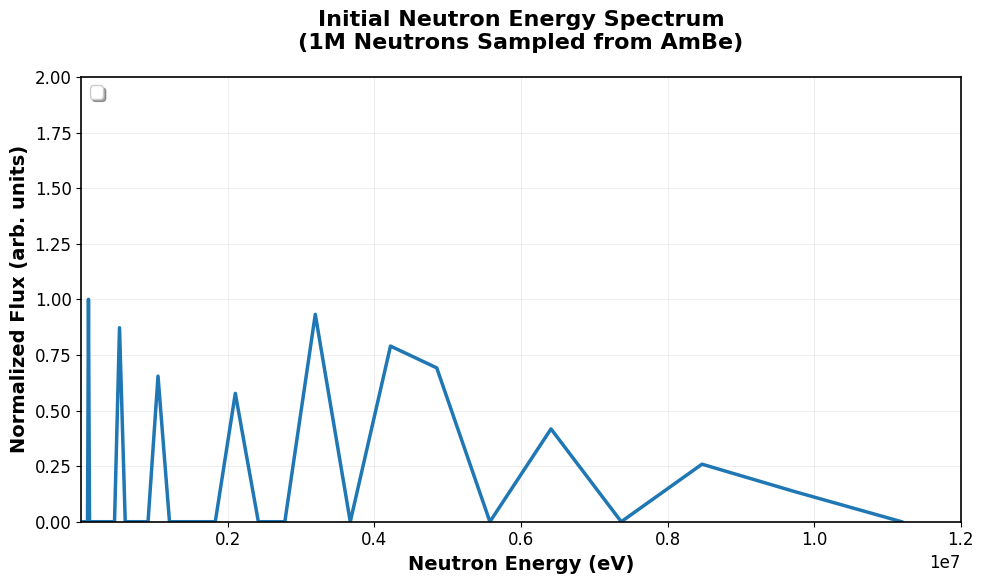

In [88]:
# plot only initial neutron spectrum (for clarity)
plt.figure(figsize=(10, 6))
plt.plot(energy_centers_eV, hist_initial_norm)
plt.xlabel('Neutron Energy (eV)', fontsize=14, fontweight='bold')
plt.ylabel('Normalized Flux (arb. units)', fontsize=14, fontweight='bold')
plt.title('Initial Neutron Energy Spectrum\n(1M Neutrons Sampled from AmBe)', fontsize=16, fontweight='bold', pad=20)
plt.xlim(0.01, 12e6)
plt.ylim(0, 2)
plt.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.15, which='minor', linestyle=':', linewidth=0.3)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, loc='upper left')
plt.tight_layout()
plt.show()

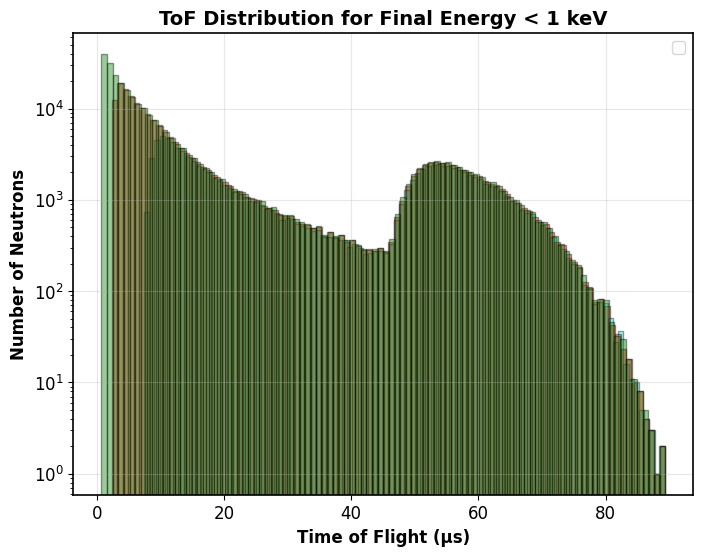

In [97]:
# show the TOF distribution only for the neutrons under 1 kev final energy
fig = plt.figure(figsize=(8, 6))
plt.hist(tof_total[(survived) & (E_final_eV < 1)]/1e3, bins=100, alpha=0.4, color='cyan', edgecolor='black')
plt.hist(tof_total[(survived) & (E_final_eV < 1e1)]/1e3, bins=100, alpha=0.4, color='red', edgecolor='black')
plt.hist(tof_total[(survived) & (E_final_eV < 1e2)]/1e3, bins=100, alpha=0.4, color='green', edgecolor='black')
# plt.hist(tof_total[(survived) & (E_final_eV < 1e3)]/1e3, bins=100, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.title('ToF Distribution for Final Energy < 1 keV', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
# plt.axvline(np.median(tof_total[(survived) & (E_final_eV < 1e3)])/1e3, color='r', linestyle='--', 
        #    linewidth=2, label=f'Median: {np.median(tof_total[(survived) & (E_final_eV < 1e3)])/1e3:.2f} μs')
plt.legend()
plt.show()

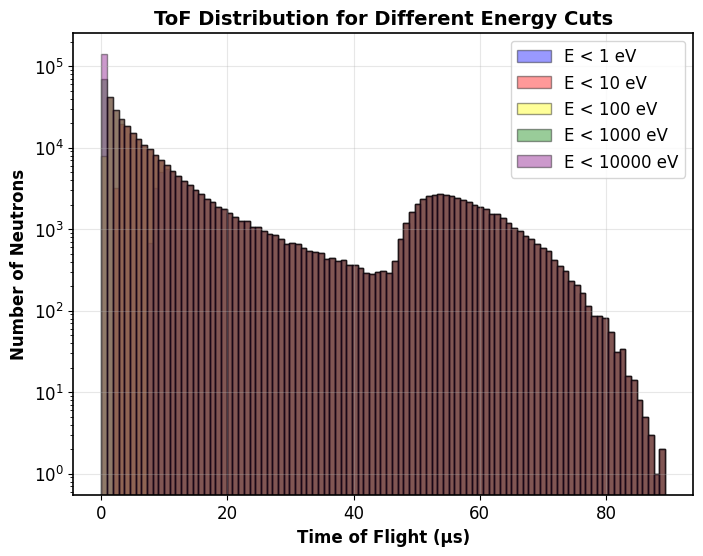

In [112]:
fig = plt.figure(figsize=(8, 6))

# masks
m1 = (survived) & (E_final_eV < 1)
m2 = (survived) & (E_final_eV < 1e1)
m3 = (survived) & (E_final_eV < 1e2)
m4 = (survived) & (E_final_eV < 1e3)
m5 = (survived) & (E_final_eV < 1e4)


# data (already scaled)
d1 = tof_total[m1] / 1e3
d2 = tof_total[m2] / 1e3
d3 = tof_total[m3] / 1e3
d4 = tof_total[m4] / 1e3
d5 = tof_total[m5] / 1e3

# common binning
all_data = np.concatenate([d1, d2, d3, d4, d5])
bins = np.linspace(all_data.min(), all_data.max(), 100)

# plots (high transparency)
plt.hist(d1, bins=bins, alpha=0.4, label='E < 1 eV', color='blue', edgecolor='black')
plt.hist(d2, bins=bins, alpha=0.4, label='E < 10 eV'    , color='red', edgecolor='black')
plt.hist(d3, bins=bins, alpha=0.4, label='E < 100 eV', color='yellow', edgecolor='black')
plt.hist(d4, bins=bins, alpha=0.4, label='E < 1000 eV', color='green', edgecolor='black')
plt.hist(d5, bins=bins, alpha=0.4, label='E < 10000 eV', color='purple', edgecolor='black')

plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.yscale('log')
# plt.xscale('log')
plt.title('ToF Distribution for Different Energy Cuts', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

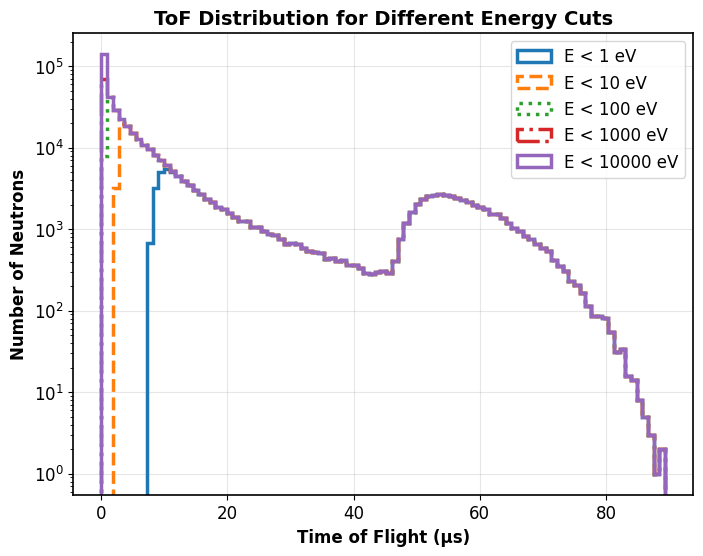

In [113]:
fig = plt.figure(figsize=(8, 6))

plt.hist(d1, bins=bins, histtype='step', linewidth=2.5, linestyle='-',  label='E < 1 eV')
plt.hist(d2, bins=bins, histtype='step', linewidth=2.5, linestyle='--', label='E < 10 eV')
plt.hist(d3, bins=bins, histtype='step', linewidth=2.5, linestyle=':',  label='E < 100 eV')
plt.hist(d4, bins=bins, histtype='step', linewidth=2.5, linestyle='-.', label='E < 1000 eV')
plt.hist(d5, bins=bins, histtype='step', linewidth=2.5, linestyle='-',  label='E < 10000 eV')


plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.title('ToF Distribution for Different Energy Cuts', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

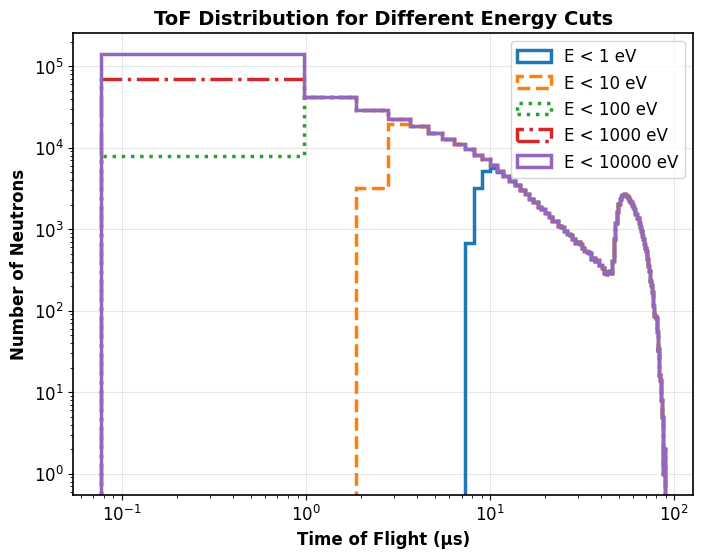

In [114]:
fig = plt.figure(figsize=(8, 6))

plt.hist(d1, bins=bins, histtype='step', linewidth=2.5, linestyle='-',  label='E < 1 eV')
plt.hist(d2, bins=bins, histtype='step', linewidth=2.5, linestyle='--', label='E < 10 eV')
plt.hist(d3, bins=bins, histtype='step', linewidth=2.5, linestyle=':',  label='E < 100 eV')
plt.hist(d4, bins=bins, histtype='step', linewidth=2.5, linestyle='-.', label='E < 1000 eV')
plt.hist(d5, bins=bins, histtype='step', linewidth=2.5, linestyle='-',  label='E < 10000 eV')


plt.xlabel('Time of Flight (μs)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Neutrons', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.xscale('log')
plt.title('ToF Distribution for Different Energy Cuts', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [84]:
from lib_neutrons import (
    ENDF_H1_DATA, ENDF_C12_DATA,
    get_endf_cross_sections,
    mean_free_path_hdpe_endf,
)
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

print('✓ ENDF data and MFP functions loaded from lib_neutrons.py')

# ===================================================================
# CALCULATIONS
# ===================================================================

print("="*80)
print("📏 NEUTRON MEAN FREE PATH IN HDPE (ENDF/B-VIII.0 DATA)")
print("="*80)

# Energy range
energies_eV = np.logspace(0, 7, 1000)  # 1 eV to 10 MeV

# Calculate with ENDF data
mfp_endf, n_H, n_C, sigma_H_endf, sigma_C_endf = mean_free_path_hdpe_endf(energies_eV)

# Print properties
print("\n🔬 HDPE PROPERTIES:")
print(f"   Density: 0.95 g/cm³")
print(f"   H number density: {n_H:.3e} nuclei/cm³")
print(f"   C number density: {n_C:.3e} nuclei/cm³")
print(f"\n📊 DATA SOURCE: ENDF/B-VIII.0 (Evaluated Nuclear Data File)")
print(f"   H-1: MAT 125, Total cross-section")
print(f"   C-12: MAT 600, Total cross-section")
print(f"   Interpolation: Cubic spline in log-log space")

print("\n📊 MEAN FREE PATH at KEY ENERGIES:")
print("-" * 75)
print(f"{'Energy':<15} {'σ_H (barns)':<15} {'σ_C (barns)':<15} {'λ (cm)':<15}")
print("-" * 75)

key_energies = [0.025, 1, 10, 100, 1e3, 10e3, 100e3, 1e6, 5e6, 10e6]
for E in key_energies:
    mfp_val, _, _, sig_H, sig_C = mean_free_path_hdpe_endf(E)
    
    # Extract scalar values from arrays (function returns arrays even for scalar input)
    mfp_val = float(mfp_val) if not hasattr(mfp_val, '__len__') else float(mfp_val[0])
    sig_H = float(sig_H) if not hasattr(sig_H, '__len__') else float(sig_H[0])
    sig_C = float(sig_C) if not hasattr(sig_C, '__len__') else float(sig_C[0])
    
    if E < 1:
        E_str = f"{E*1000:.1f} meV"
    elif E < 1e3:
        E_str = f"{E:.1f} eV"
    elif E < 1e6:
        E_str = f"{E/1e3:.0f} keV"
    else:
        E_str = f"{E/1e6:.1f} MeV"
    
    print(f"{E_str:<15} {sig_H:<15.2f} {sig_C:<15.2f} {mfp_val:<15.3f}")

print("-" * 75)

# ===================================================================
# COMPARISON PLOTS
# ===================================================================

fig = plt.figure(figsize=(16, 12))

# Plot 1: Mean Free Path (ENDF data)
ax1 = plt.subplot(2, 2, 1)
plt.loglog(energies_eV, mfp_endf, 'b-', linewidth=3, label='HDPE (ENDF/B-VIII.0)')

plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='1 cm')
plt.axhline(y=10.0, color='g', linestyle='--', alpha=0.5, label='10 cm')
plt.axvline(0.025, color='purple', linestyle=':', alpha=0.7, label='Thermal (25 meV)')
plt.axvline(1e6, color='orange', linestyle=':', alpha=0.7, label='1 MeV')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Mean Free Path (cm)', fontsize=13, fontweight='bold')
plt.title('Neutron Mean Free Path in HDPE (ENDF Data)', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)
plt.ylim(0.1, 10)

# Plot 2: Cross-sections (ENDF data)
ax2 = plt.subplot(2, 2, 2)
plt.loglog(energies_eV, sigma_H_endf, 'b-', linewidth=2.5, label='H-1 (ENDF)')
plt.loglog(energies_eV, sigma_C_endf, 'r-', linewidth=2.5, label='C-12 (ENDF)')

# Add data points
plt.loglog(ENDF_H1_DATA[:, 0], ENDF_H1_DATA[:, 1], 'bo', markersize=6, 
          alpha=0.6, label='H-1 data points')
plt.loglog(ENDF_C12_DATA[:, 0], ENDF_C12_DATA[:, 1], 'ro', markersize=6,
          alpha=0.6, label='C-12 data points')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Cross-section (barns)', fontsize=13, fontweight='bold')
plt.title('Neutron Cross-sections from ENDF/B-VIII.0', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)
plt.ylim(0.5, 200)

# Plot 3: Relative contributions
ax3 = plt.subplot(2, 2, 3)

Sigma_H = n_H * sigma_H_endf * 1e-24
Sigma_C = n_C * sigma_C_endf * 1e-24
Sigma_total = Sigma_H + Sigma_C

fraction_H = Sigma_H / Sigma_total * 100
fraction_C = Sigma_C / Sigma_total * 100

plt.semilogx(energies_eV, fraction_H, 'b-', linewidth=3, label='Hydrogen')
plt.semilogx(energies_eV, fraction_C, 'r-', linewidth=3, label='Carbon')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Contribution to Total Σ (%)', fontsize=13, fontweight='bold')
plt.title('H vs C Contribution (ENDF Data)', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(1, 1e7)
plt.ylim(0, 100)

# Plot 4: Collisions in 10 cm
ax4 = plt.subplot(2, 2, 4)

hdpe_thickness = 10.0
n_collisions = hdpe_thickness / mfp_endf

plt.loglog(energies_eV, n_collisions, 'b-', linewidth=3)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='1 collision')
plt.axhline(y=10, color='g', linestyle='--', alpha=0.5, label='10 collisions')
plt.axhline(y=100, color='orange', linestyle='--', alpha=0.5, label='100 collisions')

plt.xlabel('Neutron Energy (eV)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Collisions', fontsize=13, fontweight='bold')
plt.title(f'Expected Collisions in {hdpe_thickness} cm HDPE (ENDF)', 
         fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.xlim(1, 1e7)
plt.ylim(0.5, 300)

plt.tight_layout(pad=2.5)
plt.show()

# ===================================================================
# SUMMARY
# ===================================================================

print("\n" + "="*80)
print("📋 ENDF-BASED ANALYSIS SUMMARY")
print("="*80)

# Extract scalar values for summary
mfp_thermal_arr = mean_free_path_hdpe_endf(0.025)[0]
mfp_thermal = float(mfp_thermal_arr[0]) if hasattr(mfp_thermal_arr, '__len__') else float(mfp_thermal_arr)

mfp_1MeV_arr = mean_free_path_hdpe_endf(1e6)[0]
mfp_1MeV = float(mfp_1MeV_arr[0]) if hasattr(mfp_1MeV_arr, '__len__') else float(mfp_1MeV_arr)

mfp_5MeV_arr = mean_free_path_hdpe_endf(5e6)[0]
mfp_5MeV = float(mfp_5MeV_arr[0]) if hasattr(mfp_5MeV_arr, '__len__') else float(mfp_5MeV_arr)

print(f"""
✅ IMPROVEMENTS OVER SIMPLIFIED MODEL:
   • No artificial discontinuities
   • Based on evaluated nuclear data (ENDF/B-VIII.0)
   • Smooth interpolation using cubic splines
   • Realistic resonance structure captured in data points

📊 KEY RESULTS:
   • Thermal (25 meV): λ = {mfp_thermal:.3f} cm
   • 1 MeV:            λ = {mfp_1MeV:.3f} cm
   • 5 MeV:            λ = {mfp_5MeV:.3f} cm

🔬 PHYSICAL INSIGHTS:
   • H cross-section shows clear 1/v behavior at thermal energies
   • C cross-section relatively flat except at thermal energies
   • No sharp discontinuities - smooth energy dependence
   • H dominates interaction at all energies (70-85% contribution)

📐 DATA SOURCE:
   ENDF/B-VIII.0 - Latest evaluated nuclear data library
   Maintained by: National Nuclear Data Center (NNDC)
   Used by: MCNP, Geant4, OpenMC, and all major transport codes
""")

print("="*80)
